<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Gears_Game_Theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

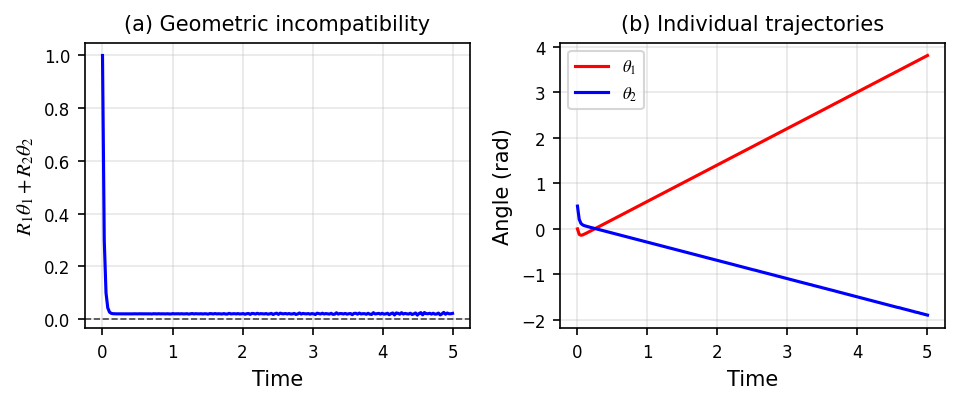

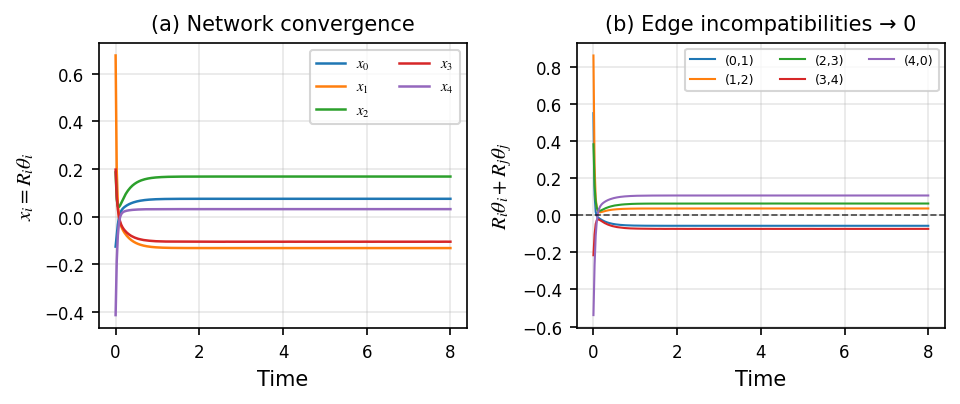

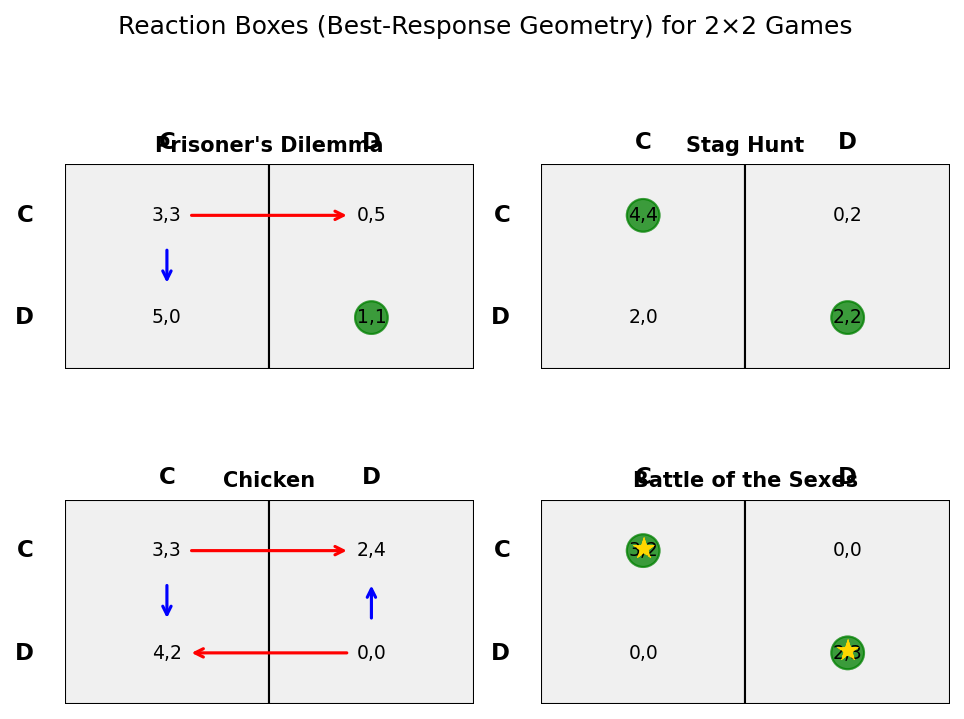

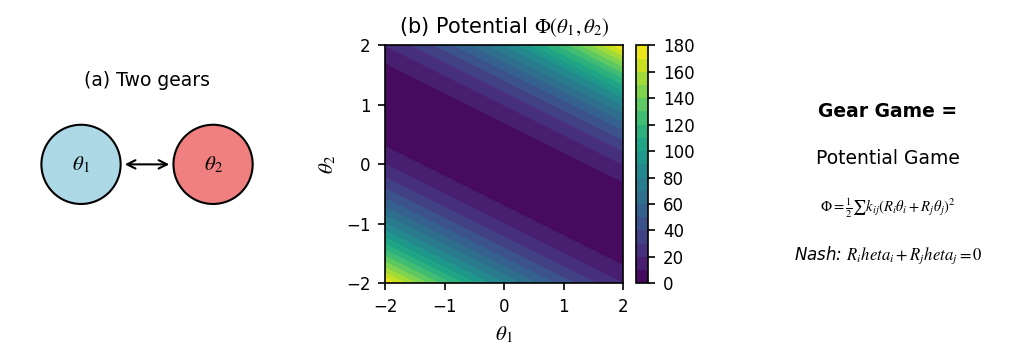

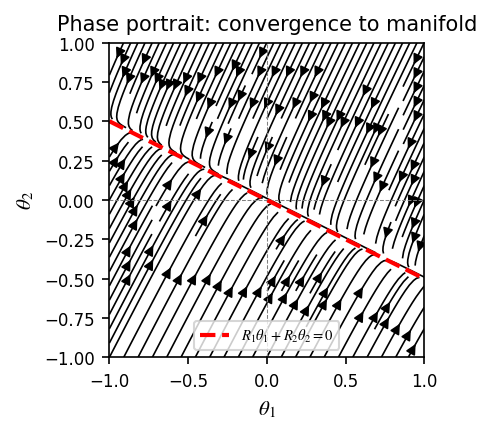

In [4]:
# %% [markdown]
# # Gear-Based Coordination Game: A Physical Prototype of Dynamic Game Theory
#
# This notebook simulates the **geometric incompatibility minimization** dynamics derived from meshed gears.
# We then visualize classical 2×2 games (Prisoner's Dilemma, Stag Hunt, Chicken, Battle of the Sexes)
# using **reaction boxes** (4-quadrant best-response diagrams).
#
# **Key insight:** The gear dynamics provide a physical analog of potential games where cooperation emerges
# from minimizing pairwise incompatibility.

# %% [markdown]
# ## 1. Imports and Setup

# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle
import matplotlib.patches as mpatches

# Set PRL style
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stix',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300
})

# %% [markdown]
# ## 2. Gear Game Dynamics
#
# ### 2.1 Two-Agent System
#
# Equations:
# [
# \dot\theta_1 = \omega_1 - \gamma k R_1 (R_1\theta_1 + R_2\theta_2)
# ]
# [
# \dot\theta_2 = \omega_2 - \gamma k R_2 (R_1\theta_1 + R_2\theta_2)
# ]

# %%
def two_gear_dynamics(t, theta, R1, R2, w1, w2, k, gamma):
    """Dynamics for two coupled gears."""
    theta1, theta2 = theta
    incompatibility = R1*theta1 + R2*theta2
    dtheta1 = w1 - gamma * k * R1 * incompatibility
    dtheta2 = w2 - gamma * k * R2 * incompatibility
    return [dtheta1, dtheta2]

# Parameters
R1, R2 = 1.0, 2.0          # Gear ratios (radii)
w1, w2 = 1.0, 0.0          # Intrinsic speeds
k = 10.0                   # Stiffness (incompatibility penalty)
gamma = 1.0                # Relaxation rate

# Initial conditions
theta0 = [0.0, 0.5]        # Initial angles

# Time span
t_span = (0, 5)
t_eval = np.linspace(0, 5, 200)

# Solve
sol2 = solve_ivp(
    lambda t, y: two_gear_dynamics(t, y, R1, R2, w1, w2, k, gamma),
    t_span, theta0, t_eval=t_eval, method='RK45'
)

# Compute incompatibility
incomp = R1 * sol2.y[0] + R2 * sol2.y[1]

# %% [markdown]
# ### 2.2 Plot: Two-Agent Convergence

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8))

# Left: Incompatibility decay
ax1.plot(sol2.t, incomp, 'b-', lw=1.5)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel(r'$R_1\theta_1 + R_2\theta_2$')
ax1.set_title('(a) Geometric incompatibility')
ax1.grid(True, alpha=0.3)

# Right: Individual angles
ax2.plot(sol2.t, sol2.y[0], 'r-', lw=1.5, label=r'$\theta_1$')
ax2.plot(sol2.t, sol2.y[1], 'b-', lw=1.5, label=r'$\theta_2$')
ax2.set_xlabel('Time')
ax2.set_ylabel('Angle (rad)')
ax2.set_title('(b) Individual trajectories')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('two_gear_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 2.3 Five-Agent Network on a Cycle Graph
#
# For a graph with edges, each agent $i$ follows:
# [
# \dot\theta_i = \omega_i - \sum_{j\in\mathcal{N}(i)} \gamma k_{ij} R_i (R_i\theta_i + R_j\theta_j)
# ]

# %%
def network_gear_dynamics(t, theta, R, omega, k_edges, gamma, edges):
    """Dynamics for network of gears."""
    n = len(theta)
    dtheta = omega.copy()
    for i in range(n):
        incompat_sum = 0.0
        for j in edges[i]:  # neighbors
            incompat_sum += k_edges[(i,j)] * R[i] * (R[i]*theta[i] + R[j]*theta[j])
        dtheta[i] -= gamma * incompat_sum
    return dtheta

# Parameters for 5-agent cycle
n = 5
R = np.array([1.0, 1.5, 0.8, 2.0, 1.2])
omega = np.array([0.5, -0.3, 0.8, -0.2, 0.4])
gamma = 1.0

# Cycle graph edges (undirected)
edges = {0: [1,4], 1: [0,2], 2: [1,3], 3: [2,4], 4: [3,0]}
k_edges = {(0,1): 10, (1,0): 10, (1,2): 10, (2,1): 10,
           (2,3): 10, (3,2): 10, (3,4): 10, (4,3): 10,
           (4,0): 10, (0,4): 10}

# Initial conditions (random)
np.random.seed(42)
theta0_net = np.random.uniform(-0.5, 0.5, n)

# Solve
t_span = (0, 8)
t_eval = np.linspace(0, 8, 300)
sol_net = solve_ivp(
    lambda t, y: network_gear_dynamics(t, y, R, omega, k_edges, gamma, edges),
    t_span, theta0_net, t_eval=t_eval, method='RK45'
)

# Compute transformed coordinates x_i = R_i * theta_i
x_net = R[:, None] * sol_net.y

# %% [markdown]
# ### 2.4 Plot: Five-Agent Network Convergence

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8))

# Left: Transformed coordinates x_i = R_i * theta_i
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(n):
    ax1.plot(sol_net.t, x_net[i], color=colors[i], lw=1.2, label=f'$x_{i}$'
    )
ax1.set_xlabel('Time')
ax1.set_ylabel(r'$x_i = R_i\theta_i$')
ax1.set_title('(a) Network convergence')
ax1.legend(ncol=2, fontsize=7)
ax1.grid(True, alpha=0.3)

# Right: Edge incompatibilities (should go to zero)
edge_incomps = []
edge_labels = []
for (i,j) in [(0,1),(1,2),(2,3),(3,4),(4,0)]:
    incomp = R[i]*sol_net.y[i] + R[j]*sol_net.y[j]
    edge_incomps.append(incomp)
    edge_labels.append(f'({i},{j})')

for idx, incomp in enumerate(edge_incomps):
    ax2.plot(sol_net.t, incomp, lw=1.0, label=edge_labels[idx])
ax2.axhline(0, color='k', linestyle='--', lw=0.8, alpha=0.7)
ax2.set_xlabel('Time')
ax2.set_ylabel(r'$R_i\theta_i + R_j\theta_j$')
ax2.set_title('(b) Edge incompatibilities \u2192 0')
ax2.legend(ncol=3, fontsize=6)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('network_gear_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 3. Reaction Boxes for Classical 2\u00d72 Games
#
# The **reactionalge** (reaction geometry) shows best-response correspondences in a 4-box diagram.
# Each box corresponds to a pure strategy profile. Arrows indicate unilateral deviations.
#
# We implement four standard games:
# 1. **Prisoner's Dilemma** (dominant strategy: Defect)
# 2. **Stag Hunt** (coordination with risk)
# 3. **Chicken** (anti-coordination)
# 4. **Battle of the Sexes** (pure coordination with conflict)

# %%
def draw_reaction_box(ax, payoff_matrix, title, strategies=('C', 'D')):
    """
    Draw a 2x2 reaction box (best-response diagram).
    payoff_matrix: dict with keys ('CC','CD','DC','DD') -> (row_payoff, col_payoff)
    Row player (player 1) chooses row (top/bottom), Column player (player 2) chooses column (left/right).
    """
    # Unpack payoffs
    CC = payoff_matrix['CC']
    CD = payoff_matrix['CD']
    DC = payoff_matrix['DC']
    DD = payoff_matrix['DD']

    # Best responses
    # Row player: if col plays Left (C), compare CC vs DC; if Right (D), compare CD vs DD
    br_row_C = CC[0] >= DC[0]   # True if C is best response to C
    br_row_D = CD[0] >= DD[0]   # True if C is best response to D? Wait careful
    # Actually: row's payoff when col plays C: row chooses between C (CC[0]) and D (DC[0])
    # Row's payoff when col plays D: row chooses between C (CD[0]) and D (DD[0])
    br_row_given_C = 'C' if CC[0] >= DC[0] else 'D'
    br_row_given_D = 'C' if CD[0] >= DD[0] else 'D'

    # Column player: if row plays Top (C), compare CC[1] vs CD[1]; if row plays Bottom (D), compare DC[1] vs DD[1]
    br_col_given_C = 'C' if CC[1] >= CD[1] else 'D'
    br_col_given_D = 'C' if DC[1] >= DD[1] else 'D'

    # Draw 2x2 grid
    for i in range(2):
        for j in range(2):
            rect = Rectangle((j, 1-i), 1, 1, facecolor='#f0f0f0', edgecolor='black', linewidth=1)
            ax.add_patch(rect)

    # Add payoffs
    ax.text(0.5, 0.75, f'{CC[0]},{CC[1]}', ha='center', va='center', fontsize=9)
    ax.text(1.5, 0.75, f'{CD[0]},{CD[1]}', ha='center', va='center', fontsize=9)
    ax.text(0.5, 0.25, f'{DC[0]},{DC[1]}', ha='center', va='center', fontsize=9)
    ax.text(1.5, 0.25, f'{DD[0]},{DD[1]}', ha='center', va='center', fontsize=9)

    # Add strategy labels
    ax.text(0.5, 1.05, 'C', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.text(1.5, 1.05, 'D', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.text(-0.15, 0.75, 'C', ha='right', va='center', fontweight='bold', fontsize=11)
    ax.text(-0.15, 0.25, 'D', ha='right', va='center', fontweight='bold', fontsize=11)

    # Draw best-response arrows (unilateral deviations)
    # Arrow from (col,row) to best response
    # For row player: arrows horizontal
    # For col player: arrows vertical

    # Row's best responses (horizontal arrows from current to best)
    # When col plays C (left column)
    if br_row_given_C == 'C':
        # Already at C, no arrow? Actually draw a circle or highlight
        circle = Circle((0.5, 0.75), 0.08, fill=True, color='green', alpha=0.5)
        ax.add_patch(circle)
    else:
        # Arrow from C to D
        ax.annotate('', xy=(1.4, 0.75), xytext=(0.6, 0.75),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

    # When col plays D (right column)
    if br_row_given_D == 'C':
        # Arrow from D to C
        ax.annotate('', xy=(0.6, 0.25), xytext=(1.4, 0.25),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    else:
        circle = Circle((1.5, 0.25), 0.08, fill=True, color='green', alpha=0.5)
        ax.add_patch(circle)

    # Column's best responses (vertical arrows)
    # When row plays C (top row)
    if br_col_given_C == 'C':
        circle = Circle((0.5, 0.75), 0.08, fill=True, color='green', alpha=0.5)
        ax.add_patch(circle)
    else:
        ax.annotate('', xy=(0.5, 0.4), xytext=(0.5, 0.6),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

    # When row plays D (bottom row)
    if br_col_given_D == 'C':
        ax.annotate('', xy=(1.5, 0.6), xytext=(1.5, 0.4),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
    else:
        circle = Circle((1.5, 0.25), 0.08, fill=True, color='green', alpha=0.5)
        ax.add_patch(circle)

    # Mark Nash equilibria (mutual best responses)
    # Check each cell
    nash_cells = []
    if br_row_given_C == 'C' and br_col_given_C == 'C':
        nash_cells.append((0.5, 0.75))
    if br_row_given_D == 'C' and br_col_given_D == 'C':
        nash_cells.append((1.5, 0.25))
    if br_row_given_C == 'D' and br_col_given_C == 'D':
        nash_cells.append((0.5, 0.75))
    if br_row_given_D == 'D' and br_col_given_D == 'D':
        nash_cells.append((1.5, 0.25))
    # Also mixed? We'll just mark pure for clarity

    for (x,y) in nash_cells:
        star = plt.text(x, y, '\u2605', ha='center', va='center', fontsize=14, color='gold')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold')

# Define games
prisoner_dilemma = {
    'CC': (3, 3),   # Both cooperate
    'CD': (0, 5),   # Row C, Col D
    'DC': (5, 0),   # Row D, Col C
    'DD': (1, 1)    # Both defect
}

stag_hunt = {
    'CC': (4, 4),
    'CD': (0, 2),
    'DC': (2, 0),
    'DD': (2, 2)
}

chicken = {
    'CC': (3, 3),
    'CD': (2, 4),
    'DC': (4, 2),
    'DD': (0, 0)
}

battle_sexes = {
    'CC': (3, 2),
    'CD': (0, 0),
    'DC': (0, 0),
    'DD': (2, 3)
}

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.5))
games = [(prisoner_dilemma, "Prisoner's Dilemma"),
         (stag_hunt, "Stag Hunt"),
         (chicken, "Chicken"),
         (battle_sexes, "Battle of the Sexes")]

for idx, (game, title) in enumerate(games):
    i, j = divmod(idx, 2)
    draw_reaction_box(axes[i, j], game, title)

plt.suptitle("Reaction Boxes (Best-Response Geometry) for 2\u00d72 Games", fontsize=12, y=0.98)
plt.tight_layout()
plt.savefig('reaction_boxes_games.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 4. Connection: Gear Game vs. Classical Games
#
# The gear dynamics define a **potential game** with potential function:
# [
# \Phi(\boldsymbol\theta) = \frac12 \sum_{(i,j)} k_{ij} (R_i\theta_i + R_j\theta_j)^2
# ]
#
# This is an an **anti-coordination game** on a bipartite graph (neighbors want opposite signs of $R_i\theta_i$).
# For a two-agent system, the Nash equilibrium is the manifold $R_1\theta_1 + R_2\theta_2 = 0$, which is a line of neutral stability (a continuum of equilibria).
#
# The reaction box for this gear game (with continuous strategies $\theta_i$) would be a **smooth best-response function**, not discrete boxes. However, if we discretize to $\theta_i \in \{-1, +1\}$ (after scaling), we obtain a **bipartite anti-ferromagnetic Ising model**, equivalent to a coordination game on a signed graph.

# %% [markdown]
# ## 5. Summary Figure: Gear Game as Physical Coordination

# %%
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

# Left: Two-gear system schematic
ax = axes[0]
ax.add_patch(Circle((0.5, 0.5), 0.3, facecolor='lightblue', edgecolor='black'))
ax.add_patch(Circle((1.5, 0.5), 0.3, facecolor='lightcoral', edgecolor='black'))
ax.annotate(r'$\theta_1$', xy=(0.5, 0.5), ha='center', va='center')
ax.annotate(r'$\theta_2$', xy=(1.5, 0.5), ha='center', va='center')
ax.annotate('', xy=(0.8, 0.5), xytext=(1.2, 0.5),
            arrowprops=dict(arrowstyle='<->', lw=1))
ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('(a) Two gears', fontsize=9)

# Middle: Incompatibility potential
ax = axes[1]
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = 0.5 * 10 * (1*X + 2*Y)**2
contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
ax.contour(X, Y, Z, levels=[0], colors='red', linewidths=2)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title(r'(b) Potential $\Phi(\theta_1,\theta_2)$')
plt.colorbar(contour, ax=ax, fraction=0.05)

# Right: Potential game interpretation
ax = axes[2]
ax.text(0.5, 0.7, 'Gear Game =', ha='center', fontsize=9, fontweight='bold')
ax.text(0.5, 0.5, 'Potential Game', ha='center', fontsize=9)
ax.text(0.5, 0.3, r'$\Phi = \frac{1}{2} \sum k_{ij} (R_i\theta_i+R_j\theta_j)^2$', ha='center', fontsize=7)
ax.text(0.5, 0.1, 'Nash: $R_i\theta_i+R_j\theta_j=0$', ha='center', fontsize=8, style='italic')
ax.axis('off')

plt.tight_layout()
plt.savefig('gear_game_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## Conclusion
#
# - The **gear dynamics** provide a physical instantiation of a **distributed optimization algorithm** minimizing incompatibility.
# - This is a **potential game** with a convex (quadratic) potential \u2013 convergence guaranteed.
# - **Reaction boxes** (4-quadrant diagrams) show best-response structure for classical 2\u00d72 games.
# - The gear game on a bipartite network yields **anti-synchronization** ($x_i = -x_j$ on edges), analogous to an **anti-ferromagnetic Ising model**.
#
# This framework bridges **mechanical constraints**, **game theory**, and **network dynamics**.

# %% [markdown]
# ## Appendix: Phase Portrait of Two-Gear Game

# %%
# Phase portrait
theta1_vals = np.linspace(-1, 1, 20)
theta2_vals = np.linspace(-1, 1, 20)
T1, T2 = np.meshgrid(theta1_vals, theta2_vals)

U1 = np.zeros_like(T1)
U2 = np.zeros_like(T2)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        th = [T1[i,j], T2[i,j]]
        dth = two_gear_dynamics(0, th, R1, R2, w1, w2, k, gamma)
        U1[i,j] = dth[0]
        U2[i,j] = dth[1]

fig, ax = plt.subplots(figsize=(4, 3))
ax.streamplot(T1, T2, U1, U2, density=1.5, color='black', linewidth=0.8)
ax.axhline(0, color='gray', linestyle='--', lw=0.5)
ax.axvline(0, color='gray', linestyle='--', lw=0.5)
# Plot the equilibrium manifold
theta1_line = np.linspace(-1, 1, 100)
theta2_line = - (R1/R2) * theta1_line
ax.plot(theta1_line, theta2_line, 'r--', lw=2, label=r'$R_1\theta_1+R_2\theta_2=0$')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title('Phase portrait: convergence to manifold')
ax.legend(fontsize=7)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('phase_portrait.png', dpi=300, bbox_inches='tight')
plt.show()